# Pandas et l'analyse de données (tabulaires)

User guide : https://pandas.pydata.org/docs/user_guide/10min.html  
Cheat Sheet : https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf

## 1. Charger des données

In [1]:
# charger les bibliothèques requises
import pandas as pd


In [2]:
# Charger des données locales
# df = pd.read_csv("../data/monchemin/monfichier.csv")

In [3]:
# Charger des données avec pandas depuis une URL
data_url = "https://raw.githubusercontent.com/datamisc/ts-2024/main/data.csv"
anes_data = pd.read_csv(data_url, compression="gzip")

/var/folders/rq/xsj46x_s2rg87wdksm1_jl3c0000gn/T/ipykernel_12686/431767268.py:3: DtypeWarning: Columns (8,10,11,16,18,19,20,22,23,24,26,27,28,30,31,36,38,39,1448,1449,1450,1451,1452,1455,1456,1457,1458,1459,1463,1464,1465) have mixed types. Specify dtype option on import or set low_memory=False.
  anes_data = pd.read_csv(data_url, compression="gzip")


In [4]:
# Si besoin : cd / ls / pwd
# (se déplacer, vérifier que le fichier est bien là et que le chemin est correct)

## Le codebook de l'ANES 2024
- Page officielle: https://electionstudies.org/data-center/2024-time-series-study/
- Version web: https://sda.berkeley.edu/sdaweb/docs/anes2024full/DOC/hcbk.htm
- Version pdf: https://electionstudies.org/anes_timeseries_2024_userguidecodebook_20250808/


### Hack Time

In [5]:
# Quel est le type de anes_data ?


### DataFrames

Les DataFrames sont des listes (ou des séries lorsqu'on utilise pandas) qui sont assemblées dans un tableau.

![](https://storage.googleapis.com/lds-media/images/series-and-dataframe.width-1200.png)

##### Quelques outils utiles pour les dataframes :
- `.info()` des infos sur notre df  
- `.shape` sa "forme"  
- `.columns` les colonnes  
- `.dtypes` le type des données  
- `.head()` afficher les premières observations  
- `.tail()` afficher la fin du df  
- `.describe()` description basique  

In [6]:
# Regardons le jeu de données
anes_data

,version,V240001,V200001,V160001_orig,V240002a,V240002b,V240002c,V240003,V240101a,V240101b,...,V245009,V245010,V245011,V245012,V245013,V245014,V245015,V245016,V245017,V245018
0,ANES2024TimeSeries_20250808,140001,200015,401318,2,2,2,1,,,...,-1,-1. Inapplicable,-1,-1,-1,-1,-1,-1,-1,-1
1,ANES2024TimeSeries_20250808,140002,200022,300261,2,2,2,1,,,...,-1,-1. Inapplicable,-1,-1,-1,-1,-1,-1,-1,-1
2,ANES2024TimeSeries_20250808,140003,200039,400181,2,2,2,1,,,...,-1,-1. Inapplicable,-1,-1,-1,-1,-1,-1,-1,-1
3,ANES2024TimeSeries_20250808,140004,200046,300171,2,2,2,1,,,...,-1,-1. Inapplicable,-1,-1,-1,-1,-1,-1,-1,-1
4,ANES2024TimeSeries_20250808,140005,200053,405145,2,2,2,1,,,...,-1,-1. Inapplicable,-1,-1,-1,-1,-1,-1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5516,ANES2024TimeSeries_20250808,399764,-1,-1,1,-6,1,3,0.117236,,...,0,-1. Inapplicable,-1,-1,-1,-1,-1,-1,-1,-1
5517,ANES2024TimeSeries_20250808,399815,-1,-1,1,5,2,3,1.501748,1.15260127111406,...,1,IWER76,1960,3,0,1,5,0,1,0
5518,ANES2024TimeSeries_20250808,399830,-1,-1,1,-6,1,3,1.114477,,...,2,-1. Inapplicable,-1,-1,-1,-1,-1,-1,-1,-1
5519,ANES2024TimeSeries_20250808,399841,-1,-1,4,4,2,3,1.179447,1.1924221171493,...,2,IWER75,1950,3,0,1,5,0,1,2


In [7]:
# Nous pouvons également en apprendre plus sur notre objet en utilisant la méthode `.info()`.
anes_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5521 entries, 0 to 5520
Columns: 1722 entries, version to V245018
dtypes: float64(4), int64(1664), object(54)
memory usage: 72.5+ MB


In [8]:
# Lorsque votre jeu de données est trop long, vous pourriez vouloir afficher les premières
# observations (lignes) en utilisant la méthode `.head()`.
anes_data.head()


,version,V240001,V200001,V160001_orig,V240002a,V240002b,V240002c,V240003,V240101a,V240101b,...,V245009,V245010,V245011,V245012,V245013,V245014,V245015,V245016,V245017,V245018
0,ANES2024TimeSeries_20250808,140001,200015,401318,2,2,2,1,,,...,-1,-1. Inapplicable,-1,-1,-1,-1,-1,-1,-1,-1
1,ANES2024TimeSeries_20250808,140002,200022,300261,2,2,2,1,,,...,-1,-1. Inapplicable,-1,-1,-1,-1,-1,-1,-1,-1
2,ANES2024TimeSeries_20250808,140003,200039,400181,2,2,2,1,,,...,-1,-1. Inapplicable,-1,-1,-1,-1,-1,-1,-1,-1
3,ANES2024TimeSeries_20250808,140004,200046,300171,2,2,2,1,,,...,-1,-1. Inapplicable,-1,-1,-1,-1,-1,-1,-1,-1
4,ANES2024TimeSeries_20250808,140005,200053,405145,2,2,2,1,,,...,-1,-1. Inapplicable,-1,-1,-1,-1,-1,-1,-1,-1


### Hack Time

In [9]:
# Testons tout ça ensemble !

# Obtenir plus d'info sur notre df ?
# Quelle forme à notre df ?
# Quelles sont les colonnes ?
# Quels sont leur type ?
# Quelles sont les grandes tendances de notre df ?

## 2. Exploration de données - Variables

Maintenant que vous avez vos données, l'étape suivante est de vous familiariser avec elles. 

La plupart du temps, vous vous intéressez à certains concepts spécifiques. 
- Vous avez besoin d'un moyen de sélectionner uniquement les variables liées à vos concepts.


### Sélectionner des variables (colonnes)

- Nous pouvons utiliser des crochets sur un objet DataFrame pour sélectionner une seule colonne !
- Nous pouvons également utiliser une liste de chaînes contenant les noms de colonnes pour sélectionner plusieurs colonnes !

![](https://pandas.pydata.org/docs/_images/03_subset_columns.svg)


In [10]:
# L'attribut `columns` permet d'obtenir les noms des colonnes d'un DataFrame
anes_data.columns


Index(['version', 'V240001', 'V200001', 'V160001_orig', 'V240002a', 'V240002b',
       'V240002c', 'V240003', 'V240101a', 'V240101b',
       ...
       'V245009', 'V245010', 'V245011', 'V245012', 'V245013', 'V245014',
       'V245015', 'V245016', 'V245017', 'V245018'],
      dtype='object', length=1722)

In [11]:
# Sélectionner la variable d'intention de vote
anes_data["V241042"]


0       1
1       1
2       1
3       1
4       1
       ..
5516    1
5517    1
5518   -1
5519    1
5520    1
Name: V241042, Length: 5521, dtype: int64

In [12]:
# Nous pouvons également la sauvegarder dans un nouvel objet et vérifier son type
vote_int = anes_data["V241042"]
type(vote_int)


pandas.core.series.Series

Supposons que vous souhaitiez également savoir pour qui les gens ont l'intention de voter en fonction de leur âge et de leur idéologie ? Dans ce cas, vous pourriez avoir besoin de sélectionner plusieurs variables.

In [13]:
# Sélectionner plusieurs colonnes
my_vars = [
    "V241042",  # pense aller voter ou non
    "V241043",  # pour qui a l'intention de voter
    "V241458x",  # age
    "V241177",  # autoplacement sur une échelle libéral-conservateur
]

anes_data[my_vars]


,V241042,V241043,V241458x,V241177
0,1,2,50,6
1,1,3,41,4
2,1,1,44,2
3,1,2,45,99
4,1,2,80,4
...,...,...,...,...
5516,1,-8,-2,4
5517,1,1,69,3
5518,-1,-1,-2,99
5519,1,1,28,1


In [14]:
# Sauvegarder ce sous-ensemble plus petit de variables dans my_df
my_df = anes_data[my_vars]
print(type(my_df))
print(my_df.columns)
my_df.head()

<class 'pandas.core.frame.DataFrame'>
Index(['V241042', 'V241043', 'V241458x', 'V241177'], dtype='object')


,V241042,V241043,V241458x,V241177
0,1,2,50,6
1,1,3,41,4
2,1,1,44,2
3,1,2,45,99
4,1,2,80,4


Pour éviter d'avoir toujours à vérifier le codebook, nettoyons un peu nos données en rendant les noms des colonnes plus explicites.

In [15]:
# Renommer les colonnes
my_df.columns = ["vote", "vote_int", "age", "ideologie"]
my_df.head()

my_vars = [
    "V241042",  # pense aller voter ou non
    "V241043",  # pour qui a l'intention de voter
    "V241458x",  # age
    "V241177",  # autoplacement sur une échelle libéral-conservateur
]


In [16]:
# nb: meilleure pratique par rename :
# - plus explicite
# - pas besoin de coller pile à l'ordre des colones
# - et donc on peut choisir lesquelles renommer

# my_df = my_df.rename(columns={
#     "title": "titre",
#     "publication_year": "annee",
#     "relevance_score": "score",
#     "abstract": "resume"
# })
# my_df.head()


### Méthodes utiles
Les Series et les DataFrames fournissent des méthodes très utiles pour explorer facilement les données. 
Quelques-unes des plus courantes :

- `mean()` : moyenne
- `median()` : médiane
- `std()` : écart-type
- `min()` : minimum
- `max()` : maximum
- `mode()` : mode (valeur la plus fréquente)
- `count()` : nombre d'observations
- `unique()` / `nunique()` : chaque modalité / nb de modalités
- `describe()` : statistiques descriptives
- `value_counts()` : fréquence des valeurs (tri à plat)

In [17]:
# Combien de personnes pensent aller voter ?
my_df["vote"].value_counts()

vote
 1    4619
-1     449
 2     436
-8      14
-9       3
Name: count, dtype: int64

In [18]:
# Quel pourcentage des gens pensent aller voter ?
my_df["vote"].value_counts(normalize=True)


vote
 1    0.836624
-1    0.081326
 2    0.078971
-8    0.002536
-9    0.000543
Name: proportion, dtype: float64

In [19]:
# Un peu plus propre
my_results = my_df["vote"].value_counts(normalize=True) * 100
my_results.round(1)


vote
 1    83.7
-1     8.1
 2     7.9
-8     0.3
-9     0.1
Name: proportion, dtype: float64

### Hack Time

In [20]:
# Quel est l'age moyen des répondants ?

In [21]:
# Quelle est l'idéologie moyenne des répondants ?

In [22]:
# Quelle est la proportion de personnes ayant
# l'intention de voter pour kamala harris ?

### Visualisations avec Pandas

Vous pouvez utiliser pandas pour tracer vos résultats en utilisant la méthode `.plot()` sur un objet DataFrame ou Series.

Pour plus d'informations, voir [**ici**](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html).

#### Aller plus loin

Il existe de nombreuses options pour jouer avec et améliorer une figure. 
Lorsque vous cherchez de l'aide pour changer quelque chose sur une figure, si vous avez la bonne terminologie, il est assez facile de trouver de l'aide !

#### Anatomie d'une figure
![Anatomie d'une figure](https://matplotlib.org/3.1.1/_images/anatomy.png)

<Axes: ylabel='Frequency'>

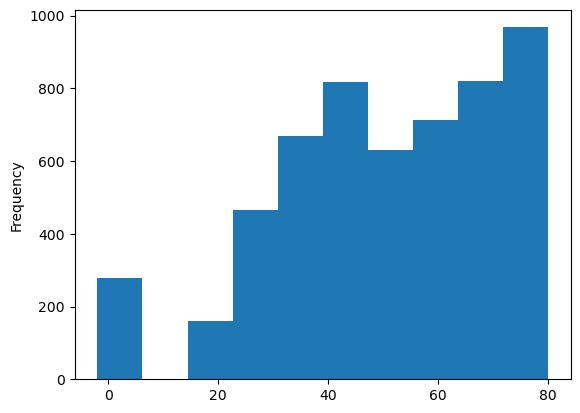

In [23]:
# Traçons la distribution de la variable age.
my_df["age"].plot(kind="hist")


<Axes: ylabel='Frequency'>

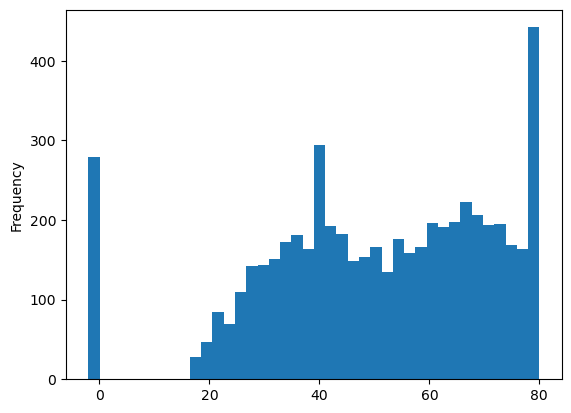

In [24]:
# Approfondir
my_df["age"].plot(kind="hist", bins=40)


<Axes: xlabel='vote'>

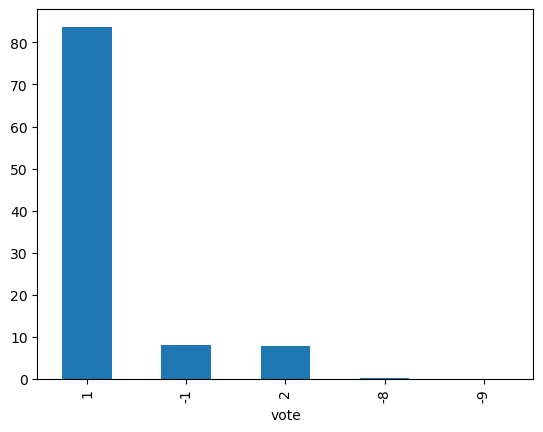

In [25]:
# Regardons l'intention de participation

# on avait déjà fait un objet results plus haut :
# cf : my_results = my_df["vote"].value_counts(normalize=True) * 100

my_results.plot(kind="bar")

## 2. Filtrer

### .loc et iloc

Récupérer une ligne/un élément avec .loc et .iloc

In [26]:
# .loc = nom des lignes et colonnes

In [27]:
# iloc = numéro index des lignes et colonnes

## Filtrer les observations (lignes)

Généralement, les données c'est "messy", sale/désordonné. La plupart du temps, vous avez besoin de filtrer certaines observations (lignes) dans votre jeu de données.
- Vous vous intéressez à certains aspects particuliers de votre jeu de données (ex : les jeunes électeurs).
- L'information est non pertinente et vous devez supprimer certaines données pour éviter de tirer de mauvaises conclusions (ex : les personnes qui refusent de répondre).

Vous avez donc besoin d'un moyen de filtrer les observations dans votre jeu de données.

- Les opérateurs relationnels permettent de sélectionner des observations.
- Il existe aussi des méthodes utiles pour vous aider dans cette tâche.

![](https://pandas.pydata.org/docs/_images/03_subset_rows.svg)

Nous avons vu que les données de l'ANES contiennent des valeurs comme -8, -9, 99, qui peuvent ou non être utiles selon le problème que l'on souhaite traiter.

Comment peut-on les gérer ?

Commençons par cette question pour illustrer :
- Les jeunes électeurs sont-ils plus libéraux ou conservateurs ?


In [28]:
# repartons des données brutes pour repartir au propre :

# Charger pandas
import pandas as pd

# Charger des données avec pandas depuis une URL
data_url = "https://raw.githubusercontent.com/datamisc/ts-2024/main/data.csv"
anes_data = pd.read_csv(data_url, compression="gzip", low_memory=False)

# Et allons chercher un peu plus de variables d'intérêt
# Sélectionner un sous ensemble de  variables et renommer
# Sélectionner un sous ensemble de variables et renommer
my_vars = [
    "V241042",  # pense aller voter ou non
    "V241043",  # pour qui a l'intention de voter
    "V241458x",  # age
    "V241177",  # autoplacement sur une échelle libéral-conservateur
    "V241156",  # Harris thermometer
    "V241157",  # Trump thermometer
    "V242425",  # Gestion covid par présidence
    "V241229",  # confiance gouvernement
    "V241233",  # corruption gouvernement
    "V241234",  # confiance aux gens
]

df = anes_data[my_vars]

df.columns = [
    "vote",
    "vote_int",
    "age",
    "ideologie",
    "harris_thrm",
    "trump_thrm",
    "covid",
    "conf_gouv",
    "conf_corrupt",
    "conf_gens",
]

df.head()

,vote,vote_int,age,ideologie,harris_thrm,trump_thrm,covid,conf_gouv,conf_corrupt,conf_gens
0,1,2,50,6,0,100,4,5,2,3
1,1,3,41,4,50,50,3,5,2,3
2,1,1,44,2,90,0,2,4,3,3
3,1,2,45,99,50,70,2,4,4,4
4,1,2,80,4,5,60,4,5,2,4


<Axes: xlabel='ideologie'>

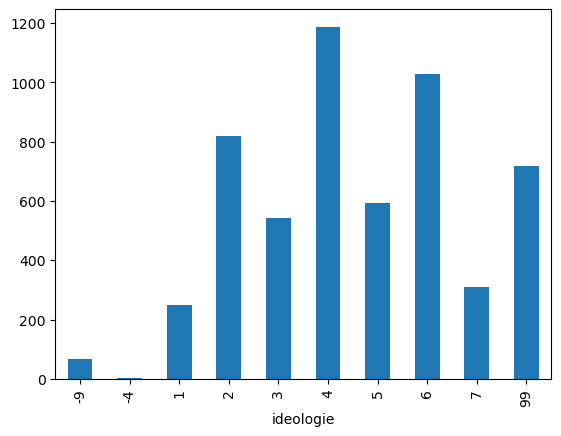

In [29]:
# Quelle est la distribution par idéologie ?
df.value_counts("ideologie").sort_index().plot(kind="bar")

# nb : .sort_index() permet de trier les barres par ordre alphanumérique de l'index
# (ici, les valeurs de la variable idéologie)
# plutôt que par effectifs

# nb2 : df.value_counts("ideologie") est ici équivalent
# à df["ideologie"].value_counts()
# que l'on avait vu précédemment

<Axes: ylabel='Frequency'>

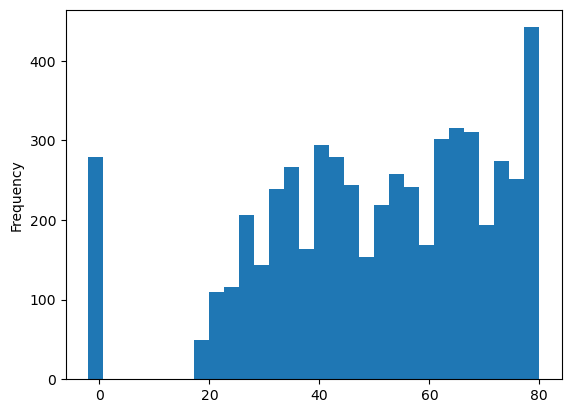

In [30]:
# Quelle est la distribution par âge ?
df["age"].plot(kind="hist", bins=30)


On a besoin de faire un peu de nettoyage dans ces variables !

In [31]:
# nettoyer la variable âge
mask_age = df["age"] >= 18
mask_age


0        True
1        True
2        True
3        True
4        True
        ...  
5516    False
5517     True
5518    False
5519     True
5520     True
Name: age, Length: 5521, dtype: bool

In [32]:
# L'âge a l'air ok désormais, mais on a perdu des observations !
df[mask_age].describe()


,vote,vote_int,age,ideologie,harris_thrm,trump_thrm,covid,conf_gouv,conf_corrupt,conf_gens
count,5242.000000,5242.000000,5242.000000,5242.000000,5242.000000,5242.000000,5242.000000,5242.000000,5242.000000,5242.000000
mean,0.897177,1.099199,53.150515,16.514880,47.391072,39.469668,1.435712,3.510683,2.726250,2.821251
std,0.796095,1.660363,17.347720,32.264763,37.514066,39.235797,2.808417,1.216335,1.484395,1.076852
min,-9.000000,-9.000000,18.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,1.000000,1.000000,39.000000,3.000000,0.000000,0.000000,1.000000,3.000000,2.000000,2.000000
50%,1.000000,1.000000,54.000000,4.000000,50.000000,30.000000,2.000000,4.000000,3.000000,3.000000
75%,1.000000,2.000000,68.000000,6.000000,85.000000,80.000000,3.000000,4.000000,4.000000,4.000000
max,2.000000,6.000000,80.000000,99.000000,100.000000,100.000000,4.000000,5.000000,5.000000,5.000000


In [33]:
# Sauvegarder le dataframe avec les données filtrées
df = df[mask_age]


**Combiner plusieurs conditions :**

In [34]:
# (ma jolie condition 1) & (ma jolie condition 2) etc.
# le & -> un "and" logique mais pour les séries pandas

# mon_filtre = (df["…"]=="…") & (df["…"]=="…")


In [35]:
# Nettoyons la variable idéologie
mask_ideo = (df["ideologie"] >= 1) & (df["ideologie"] <= 7)
mask_ideo


0        True
1        True
2        True
3       False
4        True
        ...  
5514     True
5515     True
5517     True
5519     True
5520     True
Name: ideologie, Length: 5242, dtype: bool

In [36]:
df = df[mask_ideo]
df.describe()


,vote,vote_int,age,ideologie,harris_thrm,trump_thrm,covid,conf_gouv,conf_corrupt,conf_gens
count,4490.000000,4490.000000,4490.000000,4490.000000,4490.000000,4490.000000,4490.000000,4490.000000,4490.000000,4490.000000
mean,0.886637,1.190200,53.410245,4.116927,47.662138,38.849220,1.536971,3.520713,2.795323,2.756347
std,0.724657,1.519867,17.265298,1.690302,37.805256,39.490921,2.673449,1.098874,1.294719,0.961204
min,-9.000000,-9.000000,18.000000,1.000000,-9.000000,-8.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,1.000000,1.000000,39.000000,3.000000,0.000000,0.000000,1.000000,3.000000,2.000000,2.000000
50%,1.000000,1.000000,54.000000,4.000000,50.000000,30.000000,2.000000,4.000000,3.000000,3.000000
75%,1.000000,2.000000,68.000000,6.000000,85.000000,85.000000,3.000000,4.000000,4.000000,3.000000
max,2.000000,6.000000,80.000000,7.000000,100.000000,100.000000,4.000000,5.000000,5.000000,5.000000


<Axes: ylabel='Frequency'>

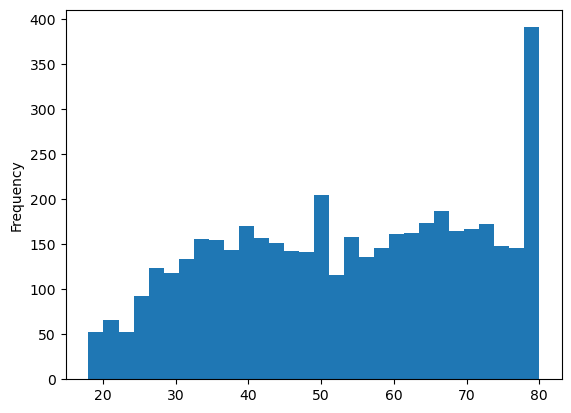

In [37]:
# Comment est distribué l'âge désormais ?
df["age"].plot(kind="hist", bins=30)


<Axes: xlabel='ideologie'>

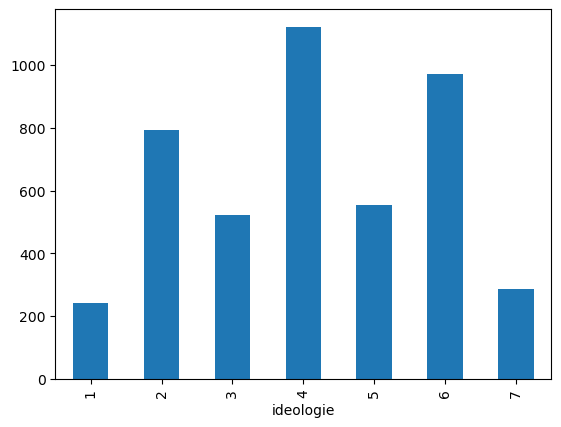

In [38]:
# Comment est distribuée l'idéologie maintenant ?
df.value_counts("ideologie").sort_index().plot(kind="bar")


### Explorons les jeunes électeur.ices

In [39]:
# Définir les jeunes électeurs
mask = df["age"] <= 25

# Quel groupe est plus libéral ? Quel groupe est plus conservateur ?
print(df[mask]["ideologie"].mean())
print(df[~mask]["ideologie"].mean())


3.7451923076923075
4.134983652498832


## 3. Grouper / croiser des observations

### Groupby

La **fonction `groupby`** de pandas permet de regrouper les données selon les valeurs d'une ou plusieurs colonnes, puis d'appliquer des opérations statistiques (comme la moyenne, la médiane, l'écart-type, etc.) sur chaque groupe.

Cela facilite la comparaison entre différentes catégories ou groupes d'observations.

La syntaxe suit ce format :
```python
df.groupby("colonne_à_grouper")[["autre_colonne"]].operation() # .mean(), .std(), etc.
```
NB : on peut directement aggréger différentes stat avec `.agg()` :  
ex : `blablabla.agg(["median","mean"])`

In [40]:
# regroupons par idéologie et calculons des statistiques sur l'age
df.groupby("ideologie")["age"].mean()  # ou median(), ou std()

ideologie
1    45.506224
2    52.722922
3    52.080614
4    52.454545
5    51.332130
6    57.889804
7    56.954704
Name: age, dtype: float64

### Hack-Time


In [41]:
# Calculez l'age médian par groupe d'idéologie


In [42]:
# Calculez l'écart type (std) d'age par groupe d'idéologie


In [43]:
# Un exemple tout prêt groupant par idéologie et calculant des indicateurs sur l'age :
df.groupby("ideologie")["age"].agg(["mean", "median", "std"])


,mean,median,std
ideologie,,,
1,45.506224,42.0,17.478587
2,52.722922,51.0,17.591879
3,52.080614,52.0,16.892341
4,52.454545,53.0,16.849287
5,51.332130,50.0,17.100749
6,57.889804,61.0,16.157001
7,56.954704,61.0,18.222442


### Crosstab

On peut utiliser la fonction `pd.crosstab()` pour réaliser des tableaux croisés entre deux variables (ou plus)

Pour de l'aide sur une fonction, vous pouvez faire appel à :
```python
help(pd.crosstab)
# ou
pd.crosstab?
```

In [44]:
# APPELEZ À L'AIDE !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


In [45]:
# Exemple de tableau croisé :
pd.crosstab(df["ideologie"], df["vote_int"])

vote_int,-9,-8,-1,1,2,3,4,5,6
ideologie,,,,,,,,,
1,0,0,27,187,9,2,2,10,4
2,0,1,90,672,17,7,2,1,4
3,1,1,40,423,40,9,1,3,3
4,11,8,195,530,263,67,9,11,28
5,7,6,93,117,278,28,3,3,19
6,2,2,114,51,764,22,2,2,12
7,0,0,35,14,236,0,0,0,2


In [46]:
# Revient à ...
df.groupby("ideologie")["vote_int"].value_counts().unstack().fillna(0).astype(int)


vote_int,-9,-8,-1,1,2,3,4,5,6
ideologie,,,,,,,,,
1,0,0,27,187,9,2,2,10,4
2,0,1,90,672,17,7,2,1,4
3,1,1,40,423,40,9,1,3,3
4,11,8,195,530,263,67,9,11,28
5,7,6,93,117,278,28,3,3,19
6,2,2,114,51,764,22,2,2,12
7,0,0,35,14,236,0,0,0,2


In [47]:
# Les valeurs absolues ne sont pas très parlantes
# pourcentage du total :
pd.crosstab(df["ideologie"], df["vote_int"], normalize=True)


vote_int,-9,-8,-1,1,2,3,4,5,6
ideologie,,,,,,,,,
1,0.000000,0.000000,0.006013,0.041648,0.002004,0.000445,0.000445,0.002227,0.000891
2,0.000000,0.000223,0.020045,0.149666,0.003786,0.001559,0.000445,0.000223,0.000891
3,0.000223,0.000223,0.008909,0.094209,0.008909,0.002004,0.000223,0.000668,0.000668
4,0.002450,0.001782,0.043430,0.118040,0.058575,0.014922,0.002004,0.002450,0.006236
5,0.001559,0.001336,0.020713,0.026058,0.061915,0.006236,0.000668,0.000668,0.004232
6,0.000445,0.000445,0.025390,0.011359,0.170156,0.004900,0.000445,0.000445,0.002673
7,0.000000,0.000000,0.007795,0.003118,0.052561,0.000000,0.000000,0.000000,0.000445


<Axes: xlabel='ideologie'>

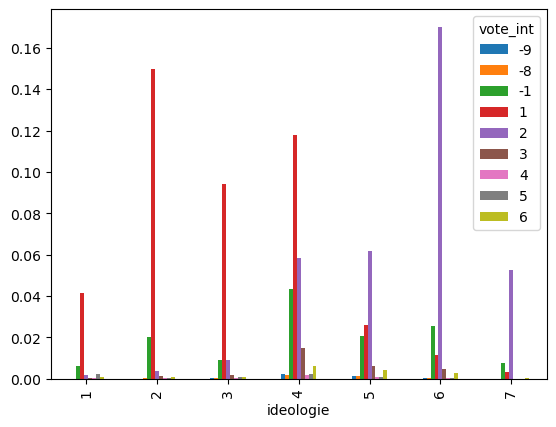

In [48]:
# Les barplots à la rescousse !
pd.crosstab(df["ideologie"], df["vote_int"], normalize=True).plot(
    kind="bar",
    # On peut jouer sur les options pour améliorer le rendu :
    # stacked=True,
    # width=2
    # figsize=(10, 5)
    # subplots=True, sharey=True
)


In [49]:
# Exemple d'un tableau croisé pourcentages en ligne
tab = pd.crosstab(df["ideologie"], df["vote_int"], normalize="index", margins=True)
tab.round(2)

vote_int,-9,-8,-1,1,2,3,4,5,6
ideologie,,,,,,,,,
1,0.00,0.00,0.11,0.78,0.04,0.01,0.01,0.04,0.02
2,0.00,0.00,0.11,0.85,0.02,0.01,0.00,0.00,0.01
3,0.00,0.00,0.08,0.81,0.08,0.02,0.00,0.01,0.01
4,0.01,0.01,0.17,0.47,0.23,0.06,0.01,0.01,0.02
5,0.01,0.01,0.17,0.21,0.50,0.05,0.01,0.01,0.03
6,0.00,0.00,0.12,0.05,0.79,0.02,0.00,0.00,0.01
7,0.00,0.00,0.12,0.05,0.82,0.00,0.00,0.00,0.01
All,0.00,0.00,0.13,0.44,0.36,0.03,0.00,0.01,0.02


In [50]:
# tab.plot(kind="bar", stacked=True, legend=False)

## 4. Recodages et modification de variables


### Créer des nouvelles variables (~ Ajout de nouvelles colonnes)

Lorsque vous recodez des variables, vous pouvez ajouter une nouvelle variable au jeu de données d'origine afin de conserver la version originale de votre variable.

![](https://pandas.pydata.org/docs/_images/05_newcolumn_1.svg)




In [51]:
df["my_new_var"] = 0
df

,vote,vote_int,age,ideologie,harris_thrm,trump_thrm,covid,conf_gouv,conf_corrupt,conf_gens,my_new_var
0,1,2,50,6,0,100,4,5,2,3,0
1,1,3,41,4,50,50,3,5,2,3,0
2,1,1,44,2,90,0,2,4,3,3,0
4,1,2,80,4,5,60,4,5,2,4,0
5,1,1,75,4,85,0,2,4,2,4,0
...,...,...,...,...,...,...,...,...,...,...,...
5514,2,-1,42,4,48,48,3,4,2,2,0
5515,1,1,80,3,100,0,1,3,3,4,0
5517,1,1,69,3,85,0,2,3,3,3,0
5519,1,1,28,1,90,0,2,2,4,2,0


In [52]:
# On peut également supprimer une colonne à l'aide de la méthode drop.
# Voyons à quoi ressemble le recoded_df si nous supprimons/dropons la variable.
df.drop("my_new_var", axis=1)

# nb: axis=1 indique que nous voulons supprimer une colonne(=1), et pas une ligne(=0)

,vote,vote_int,age,ideologie,harris_thrm,trump_thrm,covid,conf_gouv,conf_corrupt,conf_gens
0,1,2,50,6,0,100,4,5,2,3
1,1,3,41,4,50,50,3,5,2,3
2,1,1,44,2,90,0,2,4,3,3
4,1,2,80,4,5,60,4,5,2,4
5,1,1,75,4,85,0,2,4,2,4
...,...,...,...,...,...,...,...,...,...,...
5514,2,-1,42,4,48,48,3,4,2,2
5515,1,1,80,3,100,0,1,3,3,4
5517,1,1,69,3,85,0,2,3,3,3
5519,1,1,28,1,90,0,2,2,4,2


In [53]:
# Une fois satisfaits du résultat, on "sauvegarde"
df = df.drop("my_new_var", axis=1)
df

,vote,vote_int,age,ideologie,harris_thrm,trump_thrm,covid,conf_gouv,conf_corrupt,conf_gens
0,1,2,50,6,0,100,4,5,2,3
1,1,3,41,4,50,50,3,5,2,3
2,1,1,44,2,90,0,2,4,3,3
4,1,2,80,4,5,60,4,5,2,4
5,1,1,75,4,85,0,2,4,2,4
...,...,...,...,...,...,...,...,...,...,...
5514,2,-1,42,4,48,48,3,4,2,2
5515,1,1,80,3,100,0,1,3,3,4
5517,1,1,69,3,85,0,2,3,3,3
5519,1,1,28,1,90,0,2,2,4,2


### Recodage des variables avec la méthode `.replace()`

On peut utiliser la méthode/fonction `replace` pour faciliter le recodage des variables.

Essayons par exemple de recoder la variable relative à l'intention de vote :

    V241043 – PRE: FOR WHOM DOES R INTEND TO VOTE FOR PRESIDENT
        -9. Refused
        -8. Don’t know
        -1. Inapplicable
        1. Kamala Harris
        2. Donald Trump
        3. Robert F. Kennedy, Jr.
        4. Cornel West
        5. Jill Stein
        6. Another candidate {SPECIFY}



In [54]:
df

,vote,vote_int,age,ideologie,harris_thrm,trump_thrm,covid,conf_gouv,conf_corrupt,conf_gens
0,1,2,50,6,0,100,4,5,2,3
1,1,3,41,4,50,50,3,5,2,3
2,1,1,44,2,90,0,2,4,3,3
4,1,2,80,4,5,60,4,5,2,4
5,1,1,75,4,85,0,2,4,2,4
...,...,...,...,...,...,...,...,...,...,...
5514,2,-1,42,4,48,48,3,4,2,2
5515,1,1,80,3,100,0,1,3,3,4
5517,1,1,69,3,85,0,2,3,3,3
5519,1,1,28,1,90,0,2,2,4,2


In [55]:
df["vote_int"].value_counts()

vote_int
 1    1994
 2    1607
-1     594
 3     135
 6      72
 5      30
-9      21
 4      19
-8      18
Name: count, dtype: int64

In [56]:
# Commençons par filtrer les observations (lignes) qui nous intéressent
mask = (df["vote_int"] > 0) & (df["vote_int"] <= 6)
# Creation d'un nouveau dataframe
new_df = df[mask].copy()

In [57]:
# On essaie de recoder la valeur 1 en "K.Harris" pour les lignes qui respectent la condition
new_df["vote_int"].replace(1, "K.Harris")


0              2
1              3
2       K.Harris
4              2
5       K.Harris
          ...   
5513           2
5515    K.Harris
5517    K.Harris
5519    K.Harris
5520           2
Name: vote_int, Length: 3857, dtype: object

In [58]:
# Lorsqu'on a validé que c'est correct on assigne le tout à la variable initale.
new_df["vote_int"] = new_df["vote_int"].replace(1, "K.Harris")

new_df["vote_int"].value_counts()

vote_int
K.Harris    1994
2           1607
3            135
6             72
5             30
4             19
Name: count, dtype: int64

In [59]:
# Même chose pour la valeur == 2 qui correspond à Trump
# new_df["vote_int"].replace(2, "D.Trump")
# new_df["vote_int"] = new_df["vote_int"].replace(2, "D.Trump")

# Faire la même chose pour toutes les valeurs …
# Hell no

Recoder chaque catégorie une par une est **TRÈS** fastidieux ! Mais il y a des solutions.

On peut utiliser la méthode `.replace()` avec des listes ou un dictionnaire !

In [60]:
# Créer deux listes avec les anciennes et les nouvelles modalités
# ATTENTION, l'ordre des éléments des listes est important!!
old_labels = [1, 2, 3, 4, 5, 6]
new_labels = ["Harris", "Trump", "Kennedy", "West", "Stein", "Autre"]


In [61]:
# Passer à la fonction replace les anciennes et les nouvelles valeurs
new_df["vote_int"].replace(old_labels, new_labels)

# Attention : observez la différence K.Harris vs Harris

0          Trump
1        Kennedy
2       K.Harris
4          Trump
5       K.Harris
          ...   
5513       Trump
5515    K.Harris
5517    K.Harris
5519    K.Harris
5520       Trump
Name: vote_int, Length: 3857, dtype: object

In [62]:
# new_df["vote_int"].replace(old_labels, new_labels).value_counts()

> **Aparté : dictionnaires**
> Les [dictionnaires](https://docs.python.org/fr/3.7/tutorial/datastructures.html?highlight=dictionnaire) sont "des ensembles de paires clé-valeur, les clés devant être uniques (au sein d'un dictionnaire)". Ils sont définis entre des accolades :
>
> ```python
>dict = {"clé": "valeur", "autre_clé": "autre_valeur"}
>```
>
> Contrairement aux listes dont les éléments sont accessibles par leur position (index), les éléments d'un dictionnaire sont accessibles par leur clé.

In [63]:
# Revenons au df initial !

# Je peux donc aussi plutôt utiliser un dictionnaire pour faire le recodage
recode_dict = {
    1: "Harris",
    2: "Trump",
    3: "Kennedy",
    # etc.
    # 4: "",
    # 5: "",
    # 6: "",
}


# Et voir ce que ça donne :
df["vote_int"].replace(recode_dict).value_counts()

vote_int
Harris     1994
Trump      1607
-1          594
Kennedy     135
6            72
5            30
-9           21
4            19
-8           18
Name: count, dtype: int64

In [64]:
# quand je suis satisfait, je "sauve" dans une nouvelle variable, ou j'écrase l'ancienne
df["vote_int"] = df["vote_int"].replace(recode_dict)

# df["vote_int"].value_counts()

### Hack Time

In [65]:
# Choisissez une des deux méthodes (listes ou dictionnaire) pour terminer le recodage
# et assignez le résultat à la variable initiale


### La méthode `.cut()` (discrétiser des variables quanti)

La méthode/fonction `pd.cut()` nous permet de transformer une variable continue en catégories !

In [66]:
# On passe d'abord les bornes souhaitées,
# puis les labels correspondants

df["age_cat"] = pd.cut(
    df["age"],  # la variable à recoder
    bins=[17, 35, 50, 65, 80],  # les bornes
    labels=["18-35", "36-50", "51-65", "66+"],  # les labels
)
df["age_cat"].value_counts()

# nb : il est possible de préciser le comportement souhaité
# dans les paramètres de pd.cut
# de base : right=True / include_lowest=False

age_cat
66+      1376
36-50    1123
51-65    1113
18-35     878
Name: count, dtype: int64

In [67]:
# Je peux aussi recoder les données en quantiles automatiquement avec qcut
pd.qcut(df["trump_thrm"], q=5, duplicates="drop").value_counts()

trump_thrm
(-8.001, 0.0]    1862
(0.0, 60.0]      1060
(60.0, 85.0]      913
(85.0, 100.0]     655
Name: count, dtype: int64

In [68]:
# Si je veux visualiser :
# df["age_cat"].value_counts().sort_index().plot(kind="bar")


### Version générique avec ``.apply()``

> **Aparté : fonctions**
> Une fonction est un bloc de code réutilisable qui exécute une tâche précise.
> Au lieu de réécrire plusieurs fois les mêmes instructions, on les regroupe dans une fonction, puis on l’appelle quand on en a besoin.
>
> - on définit une fonction avec def
> - elle peut recevoir un ou plusieurs paramètres en entrée
> - elle peut renvoyer un résultat avec return
>
> ```python
> def categorie_age(age):
>     if age < 25:
>         return "jeune"
>     else:
>         return "30+"
> categorie_age(22)
> ````
>
> NB : On peut ensuite l'appliquer à une série pandas avec `.apply()`

In [69]:
# Exemple avec la fonction ci-dessus :
def categorie_age(age):
    if age < 25:
        return "jeune"
    else:
        return "30+"


categorie_age(22)

'jeune'

In [70]:
# et si on l'applique avec apply à la variable age de notre df ?
df["age"].apply(categorie_age)

# df["age"].apply(categorie_age).value_counts()

0       30+
1       30+
2       30+
4       30+
5       30+
       ... 
5514    30+
5515    30+
5517    30+
5519    30+
5520    30+
Name: age, Length: 4490, dtype: object

### Hack time

In [71]:
# Créer une fonction qui renvoie "fan de Harris"
# si le score du harris_thrm est supérieur à 75
# sinon retourner "bof"

# Piste :
# def fan2(x):
#     si condition:
#         faire des trucs
#     sinon:
#         faire d'autres trucs

# …

In [72]:
# Appliquer la fonction avec apply
# df["harris_thrm"].apply(fan2).value_counts()


## Autres

In [73]:
# isnull, isna, dropna, fillna

In [74]:
# exporter en csv

In [75]:
# Des trucs que l'on a oublié ?